In [77]:
#Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
# Filepath
filepath = '/Users/epalmer/MET4400C_Ins-obs_labs/Labs/lab_3_files/Data_Lab3'

# Important Constants
Rd = 287 # Specific gas constant of dry air
Rv = 461.5 # Specific gas constant of moist air/ water vapor
eps = Rv/Rd # Saturated vapor pressure
Lv = 2.5*10**6 # latent heat of vaporization
cp = 1004 # specific heat of air at constant pressure
C = 1.2 * 10**-3 # Bulk transfer coefficient

In [79]:
# Reading in the Lake Ella Data
data = pd.read_csv(f'{filepath}/Lake_Ella_Data_Collection.csv', header=1)
data

,t,p,Tair1,Tair2,Tair3,Tair4,Tair5,Tair6,Tw1,Tw2,...,Tw5,Tw6,Tsfc1,Tsfc2,U1,U2,U3,U4,U5,U6
0,3/6/2026 11:30 AM,1022.8,25.0,25.5,24.0,25.0,25,24.0,22.0,22.0,...,22,22.0,21.9,24.3,1.3,1.9,1.1,0.4,0.8,1.9
1,3/6/2026 11:33 AM,1022.8,25.0,25.0,25.0,25.5,26,24.0,21.0,21.0,...,22,21.4,21.5,23.5,0.5,2.9,0.6,0.5,1.3,0.5
2,3/6/2026 11:36 AM,1022.8,25.0,24.5,25.0,25.0,25,24.5,21.0,21.0,...,21,22.0,21.5,23.4,1.3,0.6,0.5,0.6,0.0,1.0
3,3/6/2026 11:39 AM,1022.7,25.2,25.0,25.0,25.0,25,24.5,21.0,21.0,...,21,21.2,21.9,23.5,0.9,2.3,1.5,0.4,0.0,1.8
4,3/6/2026 11:42 AM,1022.7,25.0,24.5,25.0,25.0,25,25.0,21.0,21.0,...,21,22.0,22.1,23.6,0.7,1.0,0.6,0.6,0.5,2.0
5,3/6/2026 11:45 AM,1022.7,25.5,25.5,25.0,25.5,25,25.1,21.5,21.5,...,22,22.0,23.0,23.5,0.8,0.9,0.7,0.7,0.7,1.4
6,3/6/2026 11:48 AM,1022.7,25.8,25.0,25.5,25.0,25,24.5,21.0,21.0,...,22,21.9,22.5,23.5,0.4,3.0,0.4,0.4,1.0,1.3
7,3/6/2026 11:51 AM,1022.7,25.5,26.0,26.0,25.5,26,25.0,21.5,21.5,...,22,22.0,21.8,23.3,1.4,0.6,0.6,0.9,0.8,1.4
8,3/6/2026 11:54 AM,1022.6,26.0,24.5,26.0,25.5,26,25.0,21.0,21.0,...,22,22.0,22.4,24.0,1.2,0.6,0.8,0.3,0.6,1.2
9,3/6/2026 11:57 AM,1022.6,26.0,26.0,26.0,26.0,26,25.0,22.5,22.5,...,23,22.0,21.7,25.5,0.0,0.7,0.8,1.2,0.4,0.4


In [80]:
# Get pressure from datafram
p = data['p'] * 10**2 # convert from hPa to Pa
p

0     102280.0
1     102280.0
2     102280.0
3     102270.0
4     102270.0
5     102270.0
6     102270.0
7     102270.0
8     102260.0
9     102260.0
10    102260.0
11    102260.0
12    102260.0
13    102250.0
14    102250.0
15    102250.0
16    102250.0
17    102250.0
18    102240.0
19    102240.0
20    102240.0
Name: p, dtype: float64

In [81]:
# Get dry bulb temperature data
Tair_cols = [f'Tair{n}' for n in range(1,6+1)] # selecting all the columns of dry bulb measurements
Tair = data[Tair_cols].mean(axis = 1) + 273.15 # Average Temperature of all air measurements in Kelvin
Tair

0     297.900000
1     298.233333
2     297.983333
3     298.100000
4     298.066667
5     298.416667
6     298.283333
7     298.816667
8     298.650000
9     298.983333
10    299.500000
11    298.933333
12    298.833333
13    299.050000
14    298.633333
15    298.516667
16    298.250000
17    299.083333
18    299.150000
19    298.866667
20    298.733333
dtype: float64

In [82]:
# Get Wet bulb temperature 
Twet_cols = [f'Tw{n}' for n in range(1,6+1)] # Selecting all the columns of wet bulb measurements
Twet = data[Twet_cols].mean(axis=1) + 273.15 # Average Temperature of all wet bulb air measurements in kelvin
Twet

0     295.066667
1     294.633333
2     294.816667
3     294.683333
4     294.816667
5     295.150000
6     295.050000
7     295.233333
8     295.100000
9     295.983333
10    296.150000
11    295.500000
12    295.133333
13    295.066667
14    294.900000
15    295.100000
16    295.983333
17    295.316667
18    295.266667
19    295.400000
20    295.150000
dtype: float64

In [83]:
Tsfc_cols = ['Tsfc1','Tsfc2'] # Surface temperature in Kelvin
Tsfc = data[Tsfc_cols].mean(axis=1) + 273.15 # Average surface temperature in Kelvin
Tsfc

0     296.25
1     295.65
2     295.60
3     295.85
4     296.00
5     296.40
6     296.15
7     295.70
8     296.35
9     296.75
10    296.65
11    293.80
12    295.50
13    295.45
14    295.95
15    295.55
16    295.45
17    295.70
18    296.10
19    296.70
20    296.50
dtype: float64

In [84]:
#Get wind speed data in m s-1
U_cols = [f'U{n}' for n in range(1,6+1)]
U = data[U_cols] #Don't average yet, as we care about the standard deviation of all the wind measurements

In [85]:
# Calculating Saturation Vapor Pressure es(T) using the Clausius-Clapeyron equation
def es(T):
    '''Calculate the Saturation Vapor Pressure using the Clausius-Clapeyron equation
    
    Parameters 
    ----------
    T : K 
    Temperature in Kelvin
    
    Returns
    ----------
    es : Pa 
    Saturation Vapor Pressure in Pascals
    '''
    #Formula es(T) = Aw * exp(-Bw/T)
    Aw = 2.53 * 10**11 # Pa
    Bw = 5420 # K
    es = Aw * np.exp(-Bw/T)

    return es 

In [86]:
# calculating Saturation vapor pressure using function
esw = es(Twet) # Saturation vapor pressure at wet bulb temperature
esw

0     2664.908748
1     2593.877659
2     2623.720675
3     2601.986509
4     2623.720675
5     2678.765586
6     2662.145058
7     2692.686591
8     2670.443799
9     2820.906152
10    2850.127309
11    2737.668037
12    2675.989093
13    2664.908748
14    2637.386549
15    2670.443799
16    2820.906152
17    2706.672024
18    2698.273018
19    2720.722142
20    2678.765586
dtype: float64

In [87]:
# Partial Pressure of water vapor
A = 0.00062 # K^-1
e = esw - A *(Tair - Twet) * p # Partial pressure of water vapor in Pa
e

0     2485.236882
1     2365.588699
2     2422.910942
3     2385.344559
4     2417.646625
5     2471.634746
6     2457.127798
7     2465.476741
8     2445.369539
9     2630.702552
10    2637.733289
11    2519.990583
12    2441.404653
13    2412.385332
14    2400.711883
15    2453.844216
16    2677.210818
17    2467.884190
18    2452.113178
19    2500.974302
20    2451.622386
dtype: float64

In [88]:
#Finding specific humidity of air
qair = 0.622 * e/p # Specific humidity in kg/kg
1000*qair

0     15.113584
1     14.385962
2     14.734558
3     14.507522
4     14.703982
5     15.032334
6     14.944104
7     14.994882
8     14.874045
9     16.001340
10    16.044104
11    15.327930
12    14.849929
13    14.674853
14    14.603841
15    14.927052
16    16.285820
17    15.012459
18    14.917981
19    15.215239
20    14.914995
dtype: float64

In [89]:
#Specific humidity at surface 
esfc = es(Tsfc)
qsfc = 0.622 * esfc/p # Specific humidity at the surface in kg/kg
1000*qsfc

0     17.440016
1     16.804358
2     16.752330
3     17.015575
4     17.174281
5     17.603960
6     17.334303
7     16.858178
8     17.551448
9     17.989515
10    17.879096
11    14.975234
12    16.651961
13    16.601976
14    17.124582
15    16.705346
16    16.601976
17    16.861475
18    17.285886
19    17.937738
20    17.718063
dtype: float64

In [90]:
# Calculating the virtual temperature of both the air and surface 
Tv = Tair * (1 + 0.61*qair) # Virtual temperature of the air in K

In [91]:
#Calculating density
rho = p/(Rd*Tv) # Density of the air in kg/m^3

In [92]:
# Calculating the momentum flux 
M = (rho * C * U.mean(axis = 1)**2)*1000 # Momentum flux in g m^-1 s^-2

In [93]:
# Calculating heat flux 
H = -rho * cp * C * U.mean(axis = 1) * (Tair - Tsfc) # Heat flux in W m^-2

In [94]:
#Latent Heat Flux
E = -rho * Lv * C * U.mean(axis = 1) * (qair - qsfc) # Latent heat flux in W m^-2
E

0     10.203400
1      9.023939
2      4.783358
3     10.252594
4      7.902932
5      7.911526
6      9.196315
7      6.275292
8      7.439099
9      4.106305
10     5.296603
11    -1.853396
12     6.281496
13     6.371400
14     8.047914
15     4.732190
16     1.420995
17     4.801684
18    10.758227
19     9.163510
20    11.096862
dtype: float64

In [95]:
np.mean(qair*1000)

np.float64(15.050786486300936)

In [96]:
sigma_U = U.std(axis = 1) # Standard deviation of the wind speed measurements in m s^-1

In [97]:
N = U.shape[-1] # Number of measurements for each wind speed column
s_U = sigma_U/np.sqrt(N) # Standard error of the mean wind speed measurements in m s^-1

In [98]:
s_Ubar = s_U/np.sqrt(U.shape[0])

In [99]:
# Error in momentum flux
s_M = M * 2 * s_Ubar/U.mean(axis = 1) #

In [100]:
# Error in sensible heat flux
s_H = H * s_Ubar/U.mean(axis = 1)

In [101]:
# Error in the latent heat flux
s_E = E * (s_Ubar/U.mean(axis = 1))

# Mean of the Fluxes

In [102]:
# Mean momentum flux 
M_mean_3m = np.mean(M) 
s_M_3m = np.sqrt(np.sum(s_M**2))/N
print(f'Mean momentum flux using 3-m data: {M_mean_3m:.1f} \u00B1 {2*s_M_3m:.1f} g m-1 s-2') #Reporting 95% confidence interval for uncertainty

Mean momentum flux using 3-m data: 1.4 ± 0.3 g m-1 s-2


In [103]:
# Mean sensible heat flux
H_mean_3m = np.mean(H)
s_H_3m = np.sqrt(np.sum(s_H**2))/N
print(f'Mean sensible heat flux using 3-m data: {H_mean_3m:.1f} \u00B1 {2*s_H_3m:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean sensible heat flux using 3-m data: -3.8 ± 0.5 W m-2


In [104]:
# Mean latent heat flux
E_mean_3m = np.mean(E)
s_E_3m = np.sqrt(np.sum(s_E**2))/N
print(f'Mean latent heat flux using 3-m data: {E_mean_3m:.1f} \u00B1 {2*s_E_3m:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean latent heat flux using 3-m data: 6.8 ± 0.7 W m-2


# Calculate Derivated variables for the full hour (Step 6)

In [105]:
# Average of saturation vaport pressure at wet bulb temp for the whole hour
esw_1h = es(np.mean(Twet)) 
esw_1h

np.float64(2689.4989762522637)

In [106]:
# Partial pressure of water vapor using 1 hour average of wet bulb temperature
#A = 0.00062 # K^-1 (already defined above, uncomment if needed)
e_1h = esw_1h-A*(np.mean(Tair)-np.mean(Twet))*np.mean(p)
e_1h

np.float64(2473.6833041887694)

In [107]:
# Specific humidity of air using 1 hour average of wet bulb temperature
qair_1h = 0.622*e_1h/np.mean(p)
1000*qair_1h

np.float64(15.046264572710879)

In [108]:
q_3mean_air = qair.mean()
q_3mean_air*1000

np.float64(15.050786486300936)

In [109]:
#Surface specific humidity in kg/kg
esfc_1h = es(np.mean(Tsfc))
qsfc_1h = 0.622*esfc_1h/np.mean(p)
qsfc_1h*1000

np.float64(17.077549648477333)

In [110]:
q_3mean_sfc = qsfc.mean()
q_3mean_sfc*1000

np.float64(17.088918935417595)

In [111]:
#Mean wind speed, m s-1
U_1h = np.mean(U.values)
U_1h

np.float64(0.9753968253968255)

In [112]:
#Standard deviation of all U observations; cannot easily use Pandas here
N_1h = U.shape[0]*U.shape[1] #Number of rows x number of columns
sigma_U_1h = np.sqrt(np.sum((U.values-U_1h)**2)/(N_1h-1))
sigma_U_1h

np.float64(0.7189644228123122)

In [113]:
#Error in 1-hour U
s_U_1h = sigma_U_1h/np.sqrt(N_1h)
s_U_1h

np.float64(0.06405044151055599)

In [114]:
# Momentum Flux density 
M_1h = rho.mean() * C * U_1h**2 * 1000 # in g m^-1 s^-2
s_M_1h = M_1h * 2 * s_U_1h/U_1h # Formula derived from error propogation
print(f'Mean momentum flux using 21-m data: {M_1h:.1f} \u00B1 {2*s_M_1h:.1f} g m-1 s-2') #Reporting 95% confidence interval for uncertainty

Mean momentum flux using 21-m data: 1.3 ± 0.4 g m-1 s-2


In [115]:
# Sensible heat Flux 
H_1h = -rho.mean() * cp * C * U_1h * np.mean((Tair-Tsfc))
s_H_1h = H_1h * (s_U_1h / U_1h) # Formula derived from error propogation
print(f'Mean sensible heat flux using 1-hr data: {H_1h:.1f} \u00B1 {2*s_H_1h:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean sensible heat flux using 1-hr data: -3.8 ± -0.5 W m-2


In [116]:
# Latent Heat Flux 
E_1h = -rho.mean() * Lv * C * U_1h * (qair_1h - qsfc_1h)
s_E_1h = E_1h * (s_U_1h / U_1h) # Formula derived from error propogation
print(f'Mean latent heat flux using 1-hr data: {E_1h:.1f} \u00B1 {2*s_E_1h:.1f} W m-2') #Reporting 95% confidence interval for uncertainty

Mean latent heat flux using 1-hr data: 7.0 ± 0.9 W m-2


# Plotting Data

In [117]:
#For simplicity, converting time to 24-hour and fractional
t = np.array([float((data['t'].values[i]).split(' ')[1][:2])+float((data['t'].values[i]).split(' ')[1][3:])/60 for i in range(len(data['t']))])

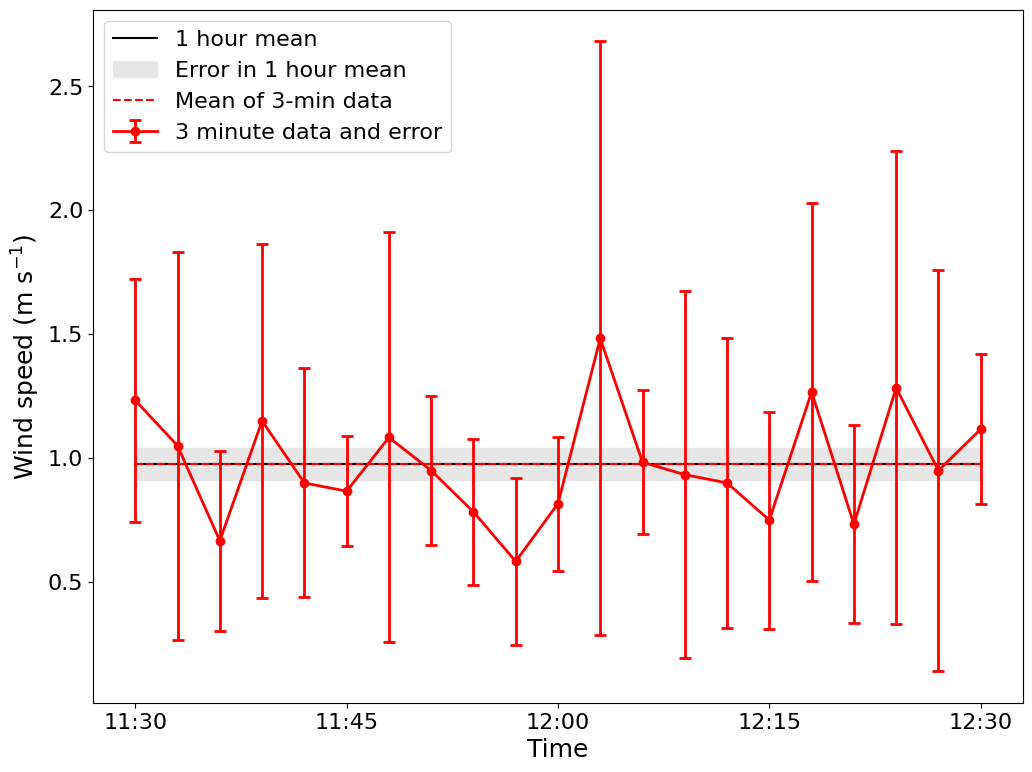

In [118]:
### Wind Plot ###

#Setting up plot 
plt.figure (figsize=(12,9))
fs = 18

# Plotting the 1 hour data as a line with shaded area representing 2 standard errors
plt.plot([11.5, 12.5], 2* [U_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[U_1h + s_U_1h], 2*[U_1h - s_U_1h], color = '0.9', label = 'Error in 1 hour mean') # Shaded area representing 2 standard errors

# Plotting the 3 minute data with errorbars which represent 2 standard erros 
plt.errorbar(t, U.mean(axis=1), yerr = 2*s_U, marker = 'o', color = 'r', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(U.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
plt.legend(fontsize=fs-2)


plt.ylabel(r'Wind speed ($\mathrm{m}$ $\mathrm{s}^{-1}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)

plt.show()


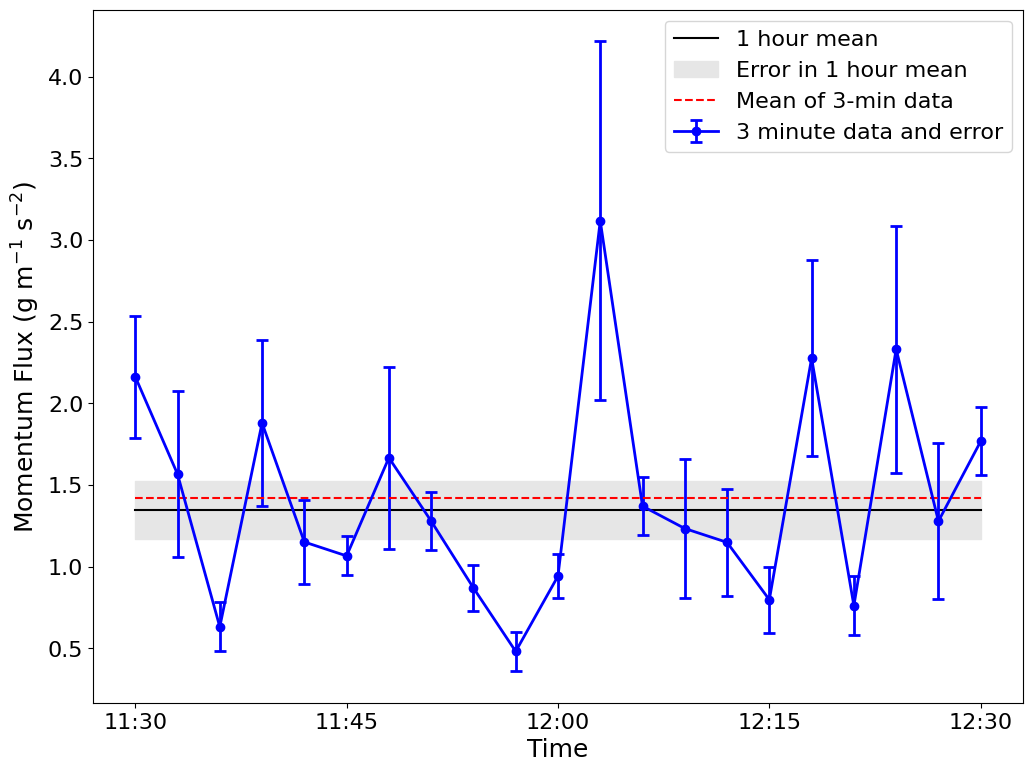

In [119]:
### Momentum Flux Plot ###

#setting up the plot
plt.figure (figsize=(12,9))
#fs = 18 # (already defined above, uncomment if needed)

# Plotting the 1 hour data as a line with a shaded area which represents 2 standard errors 
plt.plot([11.5, 12.5], 2* [M_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[M_1h + s_M_1h], 2*[M_1h - s_M_1h], color = '0.9', label = 'Error in 1 hour mean') 

#Plotting the 3 minute data with errorbars which represent 2 standard errors
plt.errorbar(t, M, yerr = 2*s_M, marker = 'o', color = 'b', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(M.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
#Legend
plt.legend(fontsize=fs-2)

#Labels and ticks
plt.ylabel(r'Momentum Flux ($\mathrm{g}$ $\mathrm{m}^{-1}$ $\mathrm{s}^{-2}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)
plt.show()

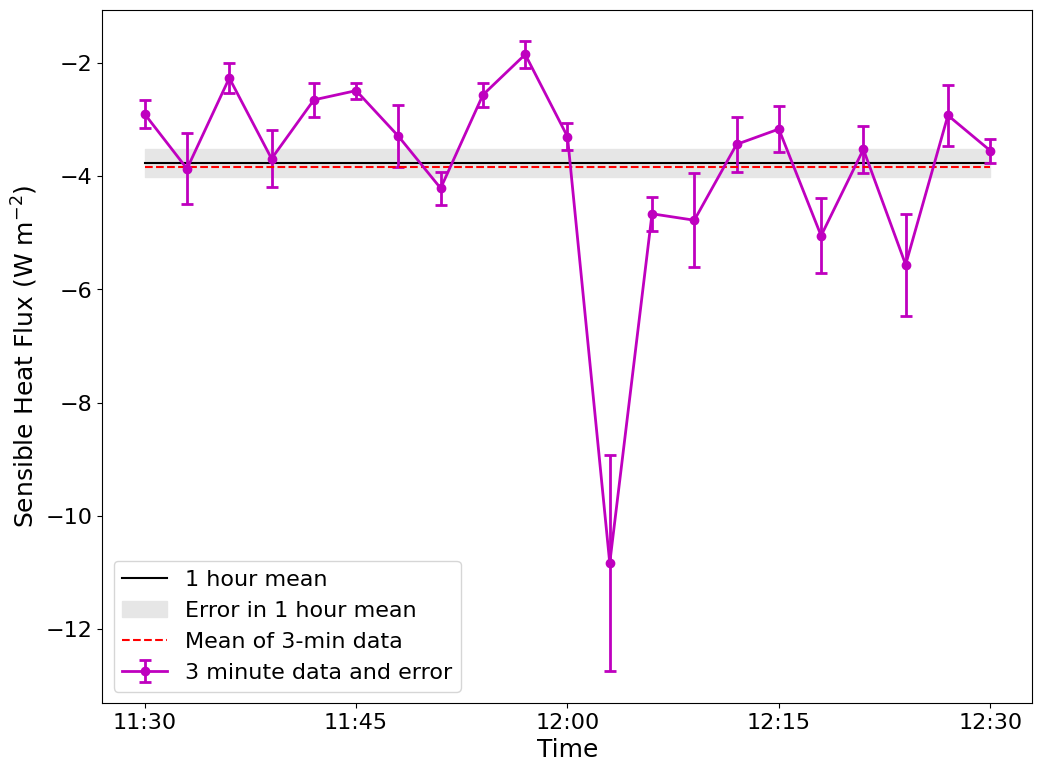

In [120]:
### Sensible Heat Flux Plot ###

# Setting up Figure
fig = plt.figure(figsize = (12,9))
#fs = 18 # (already defined above, uncomment if needed)

# Plotting the 1 hour data as a line with shaded area representing 2 standard errors
plt.plot([11.5, 12.5], 2* [H_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[H_1h + s_H_1h], 2*[H_1h - s_H_1h], color = '0.9', label = 'Error in 1 hour mean')

# Plotting the 3 minute data with errorbars which represent 2 standard errors
plt.errorbar(t, H, yerr = abs(2*s_H), marker = 'o', color = 'm', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(H.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
#Legend
plt.legend(fontsize=fs-2)

#Labels and ticks
plt.ylabel(r'Sensible Heat Flux ($\mathrm{W}$ $\mathrm{m}^{-2}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)
plt.show()

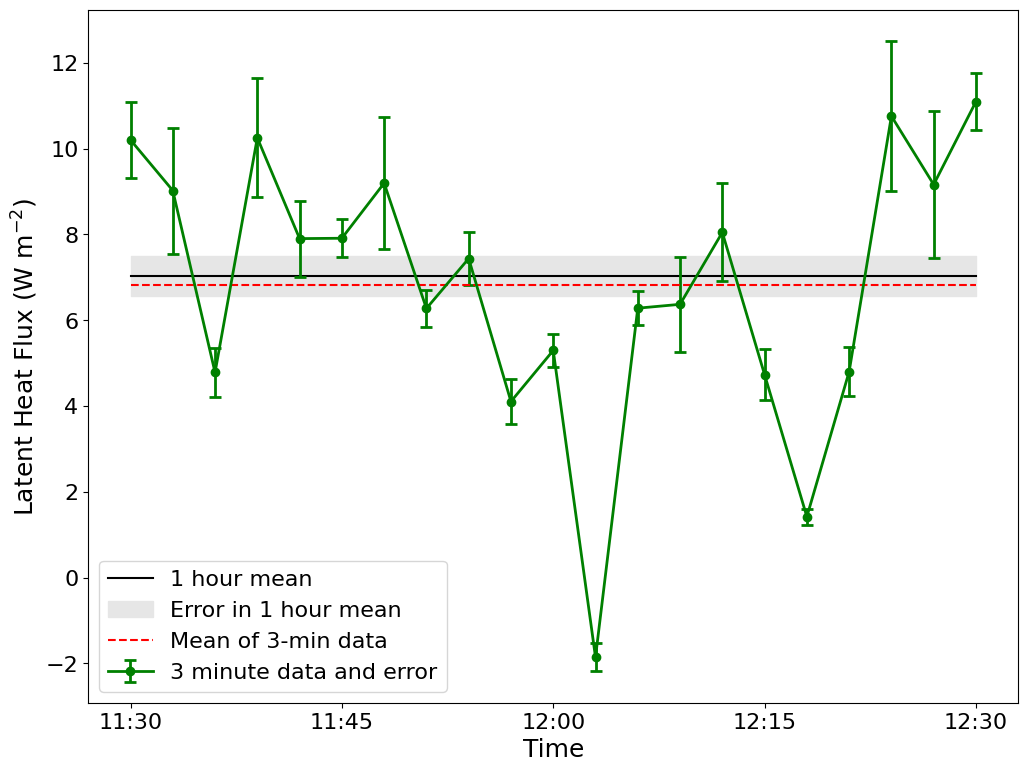

In [121]:
### Latent Heat Flux Plot ### 

# Setting up Figure
fig = plt.figure(figsize = (12,9))
#fs = 18 # (already defined above, uncomment if needed)

# Plotting the 1 hour data as a line with shaded area representing 2 standard errors
plt.plot([11.5, 12.5], 2* [E_1h], color = 'k', label = '1 hour mean') # Line plot
plt.fill_between([11.5, 12.5], 2*[E_1h + s_E_1h], 2*[E_1h - s_E_1h], color = '0.9', label = 'Error in 1 hour mean')

# Plotting the 3 minute data with errorbars which represent 2 standard errors
plt.errorbar(t, E, yerr = abs(2*s_E), marker = 'o', color = 'g', capsize = 4, capthick = 2, lw = 2 , label = '3 minute data and error')
plt.plot([11.5,12.5],2*[np.mean(E.values)],color='r',linestyle='dashed',label='Mean of 3-min data')
#Legend
plt.legend(fontsize=fs-2)

#Labels and ticks
plt.ylabel(r'Latent Heat Flux ($\mathrm{W}$ $\mathrm{m}^{-2}$)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Time',fontsize=fs)
plt.xticks([11.5,11.75,12,12.25,12.5],['11:30','11:45','12:00','12:15','12:30'],fontsize=fs-2)
plt.show()